<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana12/RetornoInversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Vamos a cargar datos
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/MyDrive/ColabNotebooks/Cursos/MetodosComputacionales2026")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import itertools

df = pd.read_csv('Semana12/Data/cuotas.csv')
df

,Partido,Local,Empate,Visitante
0,Santa,2.17,3.1,3.75
1,Millo,1.71,3.7,5.10


In [4]:
opciones = ["Local", "Empate", "Visitante"]
n_partidos = len(df)

In [5]:
combinaciones = list(itertools.product(opciones, repeat=n_partidos))

registros = []

for combo in combinaciones:
    cuota_total = 1.0
    etiqueta_partes = []

    for i, eleccion in enumerate(combo):
        partido = df.loc[i, "Partido"]
        cuota_total *= df.loc[i, eleccion]

        etiqueta_partes.append(f"{partido}:{eleccion}")

    etiqueta = " | ".join(etiqueta_partes)

    registros.append({
        "Combinacion": etiqueta,
        "Elecciones": combo,
        "Cuota Total": cuota_total
    })

df_comb = pd.DataFrame(registros)
df_comb

,Combinacion,Elecciones,Cuota Total
0,Santa:Local | Millo:Local,"(Local, Local)",3.7107
1,Santa:Local | Millo:Empate,"(Local, Empate)",8.0290
2,Santa:Local | Millo:Visitante,"(Local, Visitante)",11.0670
3,Santa:Empate | Millo:Local,"(Empate, Local)",5.3010
4,Santa:Empate | Millo:Empate,"(Empate, Empate)",11.4700
5,Santa:Empate | Millo:Visitante,"(Empate, Visitante)",15.8100
6,Santa:Visitante | Millo:Local,"(Visitante, Local)",6.4125
7,Santa:Visitante | Millo:Empate,"(Visitante, Empate)",13.8750
8,Santa:Visitante | Millo:Visitante,"(Visitante, Visitante)",19.1250


In [8]:
n = df_comb.shape[0]
n

9

In [11]:
ganancias = df_comb["Cuota Total"].to_numpy()
ganancias

array([ 3.7107,  8.029 , 11.067 ,  5.301 , 11.47  , 15.81  ,  6.4125,
       13.875 , 19.125 ])

In [50]:
# Definimos la metrica a maximizar
def fun_objetivo(w,ganancias,Capital):
  retorno =   w * ganancias * Capital - Capital
  # Necesitamos un numero
  #return -np.min(retorno)
  return -np.mean(retorno)

In [51]:
w = np.ones(n)/n
w

array([0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111])

In [52]:
Capital = 1000

In [53]:
fun_objetivo(w,ganancias,Capital)

np.float64(-170.37283950617277)

In [56]:
# Restriciones
def restriccion(w):
  return np.sum(w) - 1.

In [57]:
restricciones = {
    "type": "eq",
    "fun": restriccion
}

In [58]:
limites = [(0.,1) for _ in range(n)]

In [59]:
# En guess
w0 = np.ones(n)/n

resultado = minimize(
    fun_objetivo,
    w0,
    args=(ganancias,Capital),
    constraints=restricciones,
    bounds=limites,
    method="SLSQP",
    options={"disp":True}
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1125.0001510159357
            Iterations: 2
            Function evaluations: 21
            Gradient evaluations: 2


In [60]:
pesos_optimos = resultado.x
pesos_optimos

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 8.59673259e-08, 0.00000000e+00, 0.00000000e+00,
       1.00000000e+00])

<StemContainer object of 3 artists>

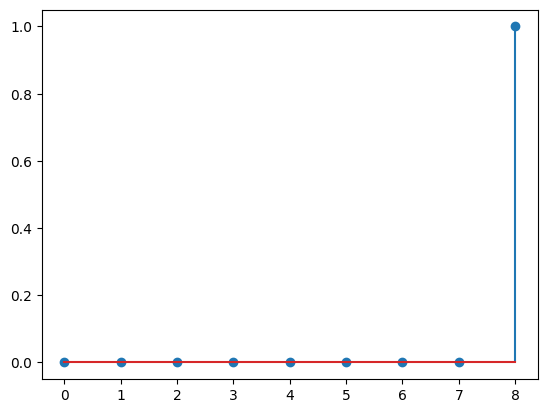

In [61]:
plt.stem(pesos_optimos)